In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [2]:
df = pd.read_csv("adult.csv")

In [3]:
df = df.replace("?", np.nan)
df = df.dropna()

In [4]:
X = df.drop("income", axis=1)
y = df["income"]

In [5]:
y = y.map({"<=50K": 0, ">50K": 1})

In [6]:
X = pd.get_dummies(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
model = SVC(
    kernel='rbf',
    C=1,
    random_state=42
)

model.fit(X_train_scaled, y_train)

SVC(C=1, random_state=42)

In [10]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8518

Confusion Matrix:
[[4246  285]
 [ 609  893]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4531
           1       0.76      0.59      0.67      1502

    accuracy                           0.85      6033
   macro avg       0.82      0.77      0.79      6033
weighted avg       0.85      0.85      0.85      6033



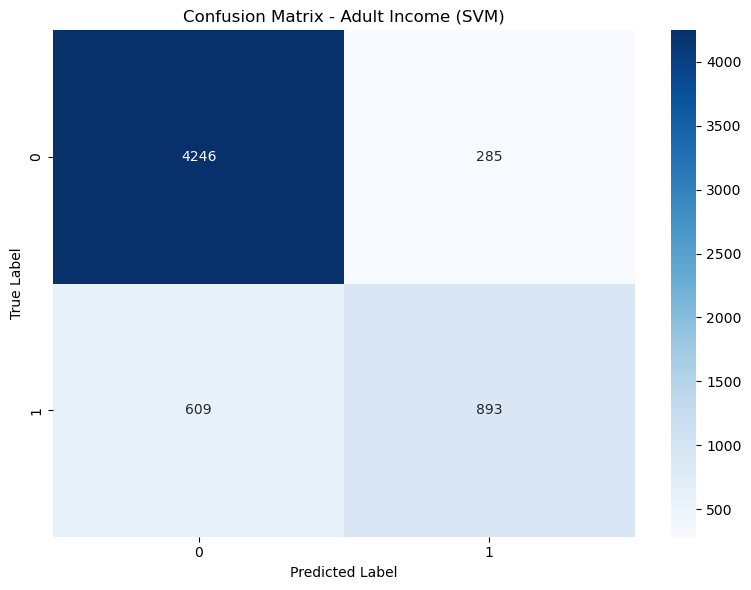

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Adult Income (SVM)")
plt.tight_layout()
plt.show()

In [12]:
print("najmeh abbbasi, sara mosavi, parnian heydari")

najmeh abbbasi, sara mosavi, parnian heydari
